In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from lib.ECP import Agent, ErgodicCP

In [2]:
# Change to True if you cannot run the program using high specs
low_performance_mode = True

In [3]:
kappa_true = 10
kappa_est = np.random.uniform(1, 100)

lambda_buy = 0.4
lambda_sell = 0.4
q_upper, q_lower = 30, -30
phi = 1e-6

simga = 0.01

T = 100
dt=1
K_upper=100
delta0=1e-8

ts = np.linspace(0, T, int(T/dt)+1)
print(ts.size)
no_of_ts = ts.size  - 1

Regret_MC = 20 if low_performance_mode else 100
regret_samples = 3 if low_performance_mode else 5

101


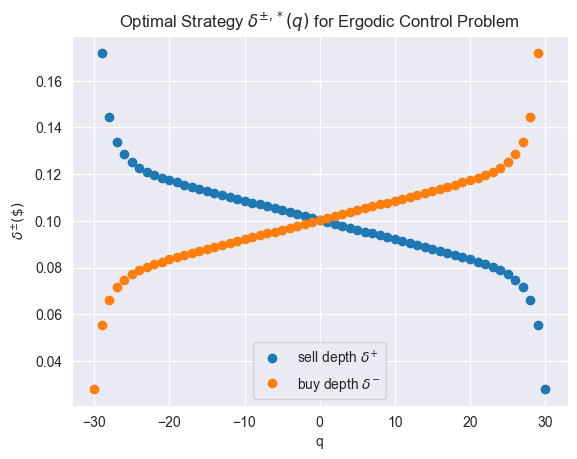

In [4]:
ErgodicCP(
    lambda_buy=lambda_buy,
    lambda_sell=lambda_sell,
    q_upper=q_upper,
    q_lower=q_lower,
    phi=phi,
    kappa=kappa_true,
).plot_EControl

In [5]:
###--- Run standard RL algorithm with exponential order fill simulations ---
MC_regret = []
MC_kappa = []
MC_pnl_regret = []
MC_objective = []

for _ in range(Regret_MC):
    regret_list = []
    kappa_list = []
    objective_list = []
    for _ in range(regret_samples):
        kappa_est = np.random.uniform(50, 100)

        agent = Agent(
            lambda_buy=lambda_buy,
            lambda_sell=lambda_sell,
            q_upper=q_upper,
            q_lower=q_lower,
            phi=phi,
            kappa_est=kappa_est,
            T=T,
            dt=dt,
            K_upper=K_upper,
            delta0=delta0,
        )
        agent.learning(sigma=simga, kappa_true=kappa_true, fill_intensity="exponential", a_true=0, b_true=0)

        kappa_list.append(agent.kappa_learnlist)
        regret_list.append(agent.regret(kappa_true=kappa_true))
        objective_list.append(agent.objective)

    kappa_list = np.array(kappa_list)
    regret_list = np.array(regret_list)
    objective_list = np.array(objective_list)

    mean_pnl = np.mean(objective_list, axis=0)
    max_pnl = np.max(objective_list, axis=0)
    pnl_regret_list = max_pnl - objective_list

    MC_regret.append(np.mean(regret_list, axis=0))
    MC_kappa.append(np.mean(kappa_list, axis=0))
    MC_pnl_regret.append(np.mean(pnl_regret_list, axis=0))
    MC_objective.append(mean_pnl)


MC_kappa = np.array(MC_kappa)
MC_regret = np.array(MC_regret)
MC_pnl_regret = np.array(MC_pnl_regret)
MC_objective = np.array(MC_objective)


0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722
0.02930885109035722


In [6]:
###--- Run standard RL algorithm with logistic order fill simulations ---
MC_logistic_regret = []
MC_logistic_pnl_regret = []
MC_logistic_kappa = []
MC_logistic_objective = []

logistic_gamma = 0.07107434986158481

for _ in range(Regret_MC):
    objective_list = []
    regret_list = []
    kappa_list = []
    for _ in range(regret_samples):
        kappa_est = np.random.uniform(50, 100)

        agent = Agent(
            lambda_buy=lambda_buy,
            lambda_sell=lambda_sell,
            q_upper=q_upper,
            q_lower=q_lower,
            phi=phi,
            kappa_est=kappa_est,
            T=T,
            dt=dt,
            K_upper=K_upper,
            delta0=delta0,
        )
        agent.learning(sigma=simga, kappa_true=kappa_true, fill_intensity="logistic", a_true=-2, b_true=10)

        kappa_list.append(agent.kappa_learnlist)
        regret_list.append(agent.regret_logistic(logistic_gamma=logistic_gamma))
        objective_list.append(agent.objective)

    kappa_list = np.array(kappa_list)
    regret_list = np.array(regret_list)
    objective_list = np.array(objective_list)

    max_pnl = np.max(objective_list, axis=0)
    mean_pnl = np.mean(objective_list, axis=0)
    pnl_logistic_regret_list = max_pnl - objective_list

    MC_logistic_regret.append(np.mean(regret_list, axis=0))
    MC_logistic_pnl_regret.append(np.mean(pnl_logistic_regret_list, axis=0))
    MC_logistic_kappa.append(np.mean(kappa_list, axis=0))
    MC_logistic_objective.append(mean_pnl)


MC_logistic_kappa = np.array(MC_logistic_kappa)
MC_logistic_regret = np.array(MC_logistic_regret)
MC_logistic_pnl_regret = np.array(MC_logistic_pnl_regret)
MC_logistic_objective = np.array(MC_logistic_objective)


In [9]:
df_kappa = pd.DataFrame(MC_kappa)
df_regret = pd.DataFrame(MC_regret)
df_pnl_regret = pd.DataFrame(MC_pnl_regret)
df_logistic_kappa = pd.DataFrame(MC_logistic_kappa)
df_logistic_regret = pd.DataFrame(MC_logistic_regret)
df_logistic_pnl_regret = pd.DataFrame(MC_logistic_pnl_regret)

df_kappa.to_csv("file_kappa_t" + str(no_of_ts) + ".csv", header=False, index=False)
df_regret.to_csv("file_regret_t" + str(no_of_ts) + ".csv", header=False, index=False)
df_pnl_regret.to_csv("file_pnl_regret_t" + str(no_of_ts) + ".csv", header=False, index=False)
df_logistic_kappa.to_csv("file_logistic_kappa_t" + str(no_of_ts) + ".csv", header=False, index=False)
df_logistic_regret.to_csv("file_logistic_regret_t" + str(no_of_ts) + ".csv", header=False, index=False)
df_logistic_pnl_regret.to_csv("file_logistic_pnl_regret_t" + str(no_of_ts) + ".csv", header=False, index=False)

MC_kappa = pd.read_csv("file_kappa_t" + str(no_of_ts) + ".csv", header=None, index_col=None)
MC_regret = pd.read_csv("file_regret_t" + str(no_of_ts) + ".csv", header=None, index_col=None)
MC_pnl_regret = pd.read_csv("file_pnl_regret_t" + str(no_of_ts) + ".csv", header=None, index_col=None)

MC_logistic_kappa = pd.read_csv("file_logistic_kappa_t" + str(no_of_ts) + ".csv", header=None, index_col=None)
MC_logistic_regret = pd.read_csv("file_logistic_regret_t" + str(no_of_ts) + ".csv", header=None, index_col=None)
MC_logistic_pnl_regret = pd.read_csv("file_logistic_pnl_regret_t" + str(no_of_ts) + ".csv", header=None, index_col=None)

MC_kappa = np.array(MC_kappa)
MC_regret = np.array(MC_regret)
MC_pnl_regret = np.array(MC_pnl_regret)
MC_logistic_regret = np.array(MC_logistic_regret)
MC_logistic_kappa = np.array(MC_logistic_kappa)
MC_logistic_pnl_regret = np.array(MC_logistic_pnl_regret)

[0.         0.01022873 0.02237693 0.03597785 0.05326892 0.0697757
 0.09599669 0.11491337 0.12701541 0.14680828 0.1771033  0.19633936
 0.23171584 0.25512087 0.27992245 0.30998705 0.32862353 0.34151795
 0.36283638 0.3797667  0.40813049 0.44629827 0.47375001 0.50528701
 0.53951372 0.56086689 0.59688546 0.61022691 0.642345   0.67159409
 0.71715759 0.74749185 0.76813453 0.78621515 0.80211268 0.82549347
 0.84246441 0.869827   0.88981333 0.9151366  0.93953073 0.96041553
 0.99270684 1.01422805 1.04537749 1.0718803  1.0926974  1.11522667
 1.12783189 1.17641328 1.18987779 1.22130583 1.2455836  1.27273718
 1.31074546 1.33649773 1.36381957 1.39259223 1.41666161 1.44273209
 1.47802527 1.50513192 1.5395841  1.57100085 1.58650891 1.61950208
 1.65382906 1.66879875 1.68408544 1.72822046 1.75781489 1.78333887
 1.81401707 1.83546127 1.86023913 1.8789381  1.9191278  1.95495544
 1.96829565 1.9942828  2.03886153 2.07441159 2.10152561 2.12849271
 2.16624209 2.20124381 2.23326638 2.26173851 2.28961049 2.31000

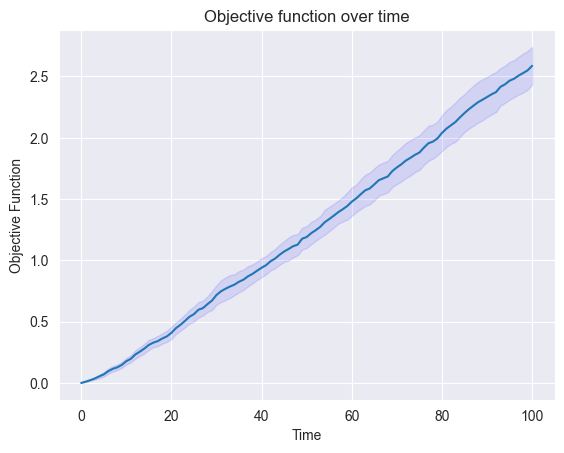

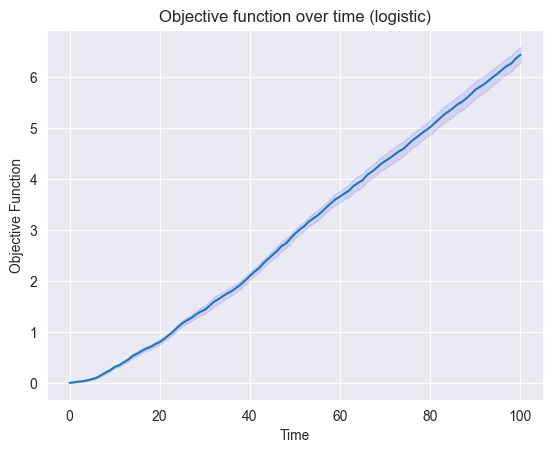

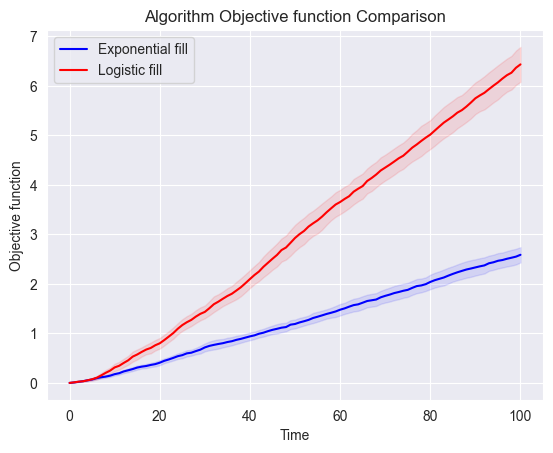

In [12]:
std = np.std(MC_objective, axis=0)
ci = 1.96 * std/np.sqrt(Regret_MC)
y = np.mean(MC_objective, axis=0)

std_logistic = np.std(MC_logistic_objective, axis=0)
ci_logistic = 1.96 * std_logistic/np.sqrt(Regret_MC)
y_logistic = np.mean(MC_logistic_objective, axis=0)
print(y)
print(y_logistic)

fig, ax = plt.subplots()
ax.plot(ts, y)
ax.fill_between(ts, (y-ci), (y+ci), color='b', alpha=.1)
plt.xlabel("Time")
plt.ylabel("Objective Function")
plt.title("Objective function over time")
plt.show()

fig, ax = plt.subplots()
ax.plot(ts, y_logistic)
ax.fill_between(ts, (y_logistic-ci), (y_logistic+ci), color='b', alpha=.1)
plt.xlabel("Time")
plt.ylabel("Objective Function")
plt.title("Objective function over time (logistic)")
plt.show()

fig, ax = plt.subplots()
ax.plot(ts, y, color='blue', label='Exponential fill')
ax.fill_between(ts, y-ci, y+ci, color='blue', alpha=0.1)
ax.plot(ts, y_logistic, color='red', label='Logistic fill')
ax.fill_between(ts, y_logistic-ci_logistic, y_logistic+ci_logistic, color='red', alpha=0.1)
plt.xlabel("Time")
plt.ylabel("Objective function")
plt.title("Algorithm Objective function Comparison")
plt.legend()
plt.show()

[0.         0.01908012 0.03624077 0.05194871 0.06396649 0.07676856
 0.07985641 0.09024859 0.1074554  0.11697138 0.11598521 0.12605801
 0.11999037 0.12589419 0.13040146 0.12964572 0.14031809 0.15673252
 0.16472294 0.17710147 0.17804653 0.1691876  0.17104471 0.16881656
 0.1638987  0.17185438 0.16514467 0.18111207 0.17830283 0.17836259
 0.16210795 0.16108253 0.16974871 0.18097694 0.19438826 0.20031632
 0.21265423 0.21460049 0.22392301 0.22790859 0.23282332 0.24124737
 0.23826491 0.24605254 0.24421196 0.247018   0.25550975 0.26228933
 0.27899297 0.25972043 0.27556477 0.27344558 0.27847666 0.28063193
 0.27193249 0.27548908 0.27747609 0.27801229 0.28325175 0.28649013
 0.2805058  0.282708   0.27756466 0.27545677 0.28925756 0.28557324
 0.28055512 0.29489428 0.30891643 0.29409027 0.29380469 0.29758956
 0.29622021 0.30408486 0.30861585 0.31922573 0.30834488 0.3018261
 0.31779473 0.32111644 0.30584656 0.29960535 0.30180018 0.30414193
 0.2957014  0.29000853 0.28729481 0.28813153 0.2895684  0.29847

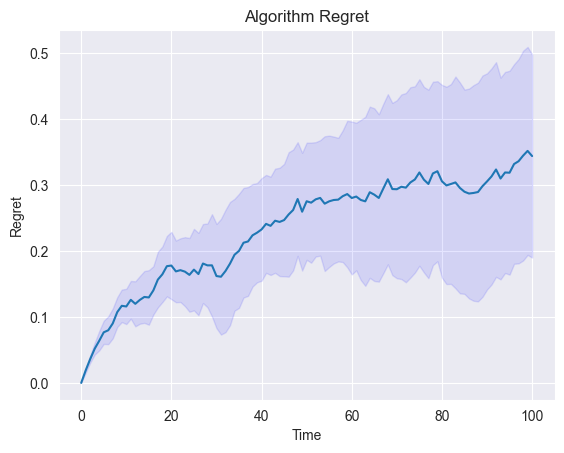

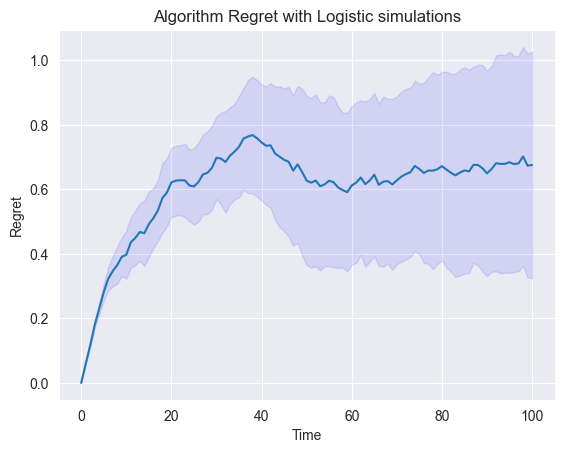

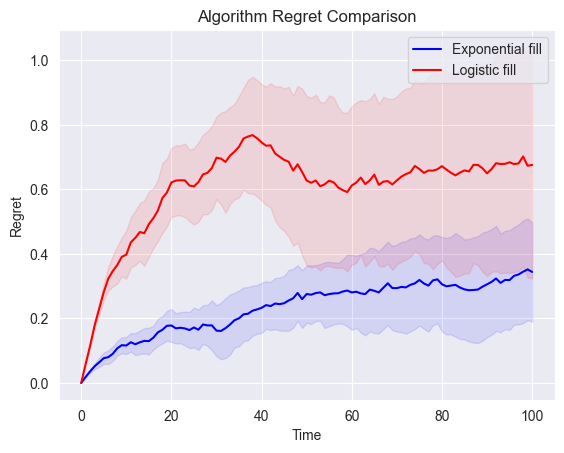

In [11]:
std = np.std(MC_regret, axis=0)
ci = 1.96 * std/np.sqrt(Regret_MC)
y = np.mean(MC_regret, axis=0)

std_logistic = np.std(MC_logistic_regret, axis=0)
ci_logistic = 1.96 * std_logistic/np.sqrt(Regret_MC)
y_logistic = np.mean(MC_logistic_regret, axis=0)

fig, ax = plt.subplots()
ax.plot(ts, y)
ax.fill_between(ts, (y-ci), (y+ci), color='b', alpha=.1)
plt.xlabel("Time")
plt.ylabel("Regret")
plt.title("Algorithm Regret")
plt.show()

fig, ax = plt.subplots()
ax.plot(ts, y_logistic)
ax.fill_between(ts, (y_logistic-ci_logistic), (y_logistic+ci_logistic), color='b', alpha=.1)
plt.xlabel("Time")
plt.ylabel("Regret")
plt.title("Algorithm Regret with Logistic simulations")
plt.show()

fig, ax = plt.subplots()
ax.plot(ts, y, color='blue', label='Exponential fill')
ax.fill_between(ts, y-ci, y+ci, color='blue', alpha=0.1)
ax.plot(ts, y_logistic, color='red', label='Logistic fill')
ax.fill_between(ts, y_logistic-ci_logistic, y_logistic+ci_logistic, color='red', alpha=0.1)
plt.xlabel("Time")
plt.ylabel("Regret")
plt.title("Algorithm Regret Comparison")
plt.legend()
plt.show()

[0.         0.01254477 0.02174594 0.03223571 0.04096596 0.05368289
 0.07651799 0.07858956 0.08107759 0.08886906 0.11600189 0.128156
 0.14618756 0.15520163 0.16418461 0.17104172 0.177039   0.17400976
 0.19745137 0.21415688 0.21543716 0.22218865 0.24114939 0.22996303
 0.24498593 0.24819954 0.26104666 0.26566108 0.27389882 0.27515784
 0.28196549 0.28912491 0.30895499 0.31098388 0.30581615 0.29180676
 0.29891709 0.27952461 0.30257895 0.29875526 0.30185331 0.31030575
 0.31915018 0.33570735 0.34344325 0.3288812  0.32165219 0.31453299
 0.31707634 0.30536606 0.3122913  0.32270001 0.32048665 0.31136696
 0.32892571 0.3210973  0.31325163 0.34434633 0.33766598 0.33269991
 0.33901775 0.3393763  0.34399412 0.35596342 0.38082963 0.40735452
 0.40219012 0.40263728 0.40742766 0.42082823 0.40366836 0.40152608
 0.41979118 0.43042925 0.436238   0.44857061 0.45625485 0.48227362
 0.50036876 0.50880223 0.51328575 0.53582236 0.50602286 0.50314087
 0.49363087 0.48571659 0.4995116  0.50876948 0.50994875 0.522658

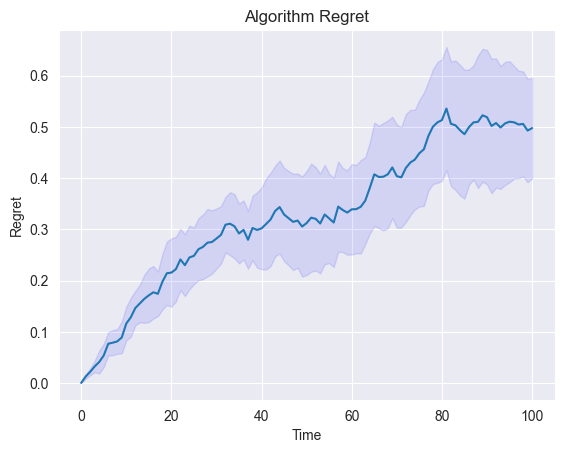

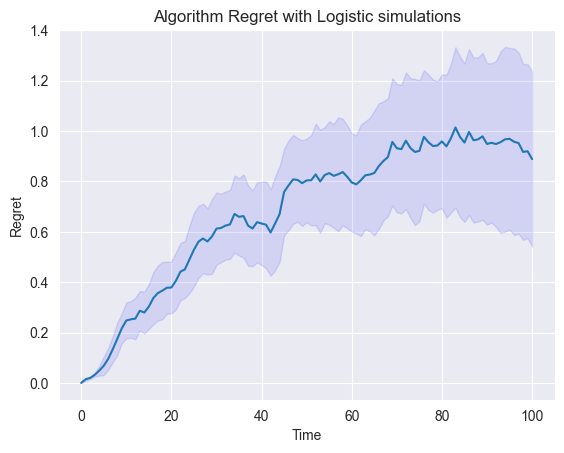

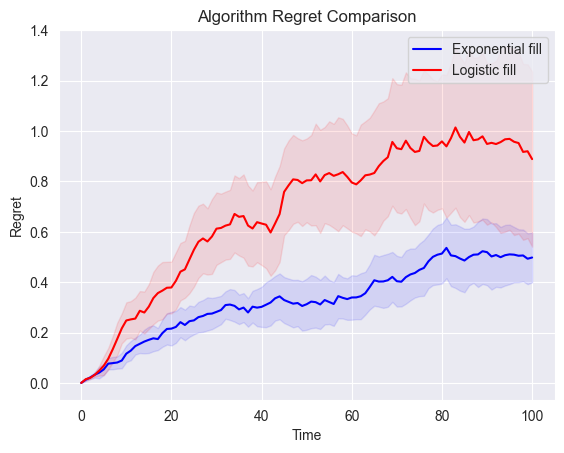

In [13]:
###--- Plot regret comparison for pnl regret ---###
std = np.std(MC_pnl_regret, axis=0)
ci = 1.96 * std/np.sqrt(Regret_MC)
y = np.mean(MC_pnl_regret, axis=0)

std_logistic = np.std(MC_logistic_pnl_regret, axis=0)
ci_logistic = 1.96 * std_logistic/np.sqrt(Regret_MC)
y_logistic = np.mean(MC_logistic_pnl_regret, axis=0)
print(y)
print(y_logistic)

fig, ax = plt.subplots()
ax.plot(ts, y)
ax.fill_between(ts, (y-ci), (y+ci), color='b', alpha=.1)
plt.xlabel("Time")
plt.ylabel("Regret")
plt.title("Algorithm Regret")
plt.show()

fig, ax = plt.subplots()
ax.plot(ts, y_logistic)
ax.fill_between(ts, (y_logistic-ci_logistic), (y_logistic+ci_logistic), color='b', alpha=.1)
plt.xlabel("Time")
plt.ylabel("Regret")
plt.title("Algorithm Regret with Logistic simulations")
plt.show()

fig, ax = plt.subplots()
ax.plot(ts, y, color='blue', label='Exponential fill')
ax.fill_between(ts, y-ci, y+ci, color='blue', alpha=0.1)
ax.plot(ts, y_logistic, color='red', label='Logistic fill')
ax.fill_between(ts, y_logistic-ci_logistic, y_logistic+ci_logistic, color='red', alpha=0.1)
plt.xlabel("Time")
plt.ylabel("Regret")
plt.title("Algorithm Regret Comparison")
plt.legend()
plt.show()

In [20]:
start = 10

y_axis = (y)[start:]
y_axis_upper = (y+ci)[start:]
x_axis = ts[start:]

# Define the quadratic model
def log_square_model(x, c, m):
    return c * (np.log(x)**2) + m

def calculate_r2(data, fit_data):
    residual = data - fit_data
    ss_res = np.sum(residual**2)
    ss_tot = np.sum((data - np.mean(data))**2)
    r_2 = 1 - ss_res / ss_tot
    return r_2

def log_model(x,c, m):
    return c * np.log(x) + m

# Use log^2 model
params, covariance = curve_fit(log_square_model, x_axis, y_axis)
c_estimated = params[0]
m_estimated = params[1]

params_upper, covariance_upper = curve_fit(log_square_model, x_axis, y_axis_upper)
c_estimated_upper = params_upper[0]
m_estimated_upper = params_upper[1]



# Use log model 
params_log, covariance_log = curve_fit(log_model, x_axis, y_axis)
c_estimated_log = params_log[0]
m_estimated_log = params_log[1]


params_upper_log, covariance_upper_log = curve_fit(log_model, x_axis, y_axis_upper)
c_estimated_upper_log = params_upper_log[0]
m_estimated_upper_log = params_upper_log[1]

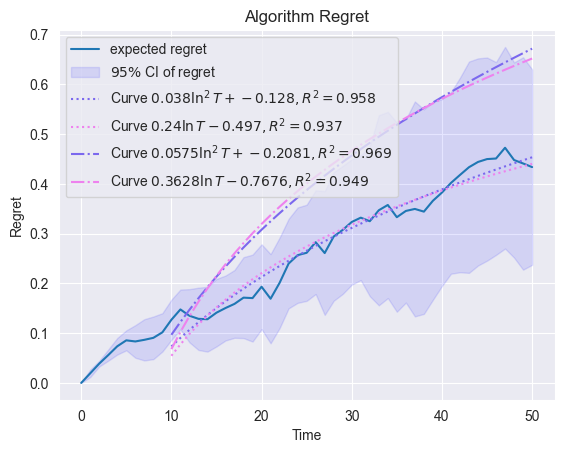

In [21]:
fig, ax = plt.subplots()
ax.plot(ts, y, label='expected regret')
ax.fill_between(ts, (y-ci), (y+ci), color='b', alpha=.1, label='$95\%$ CI of regret')

x_fit = ts[start:]
y_fit = log_square_model(x_fit, c_estimated, m_estimated)
y_fit_upper = log_square_model(x_fit, c_estimated_upper, m_estimated_upper)

y_fit_log = log_model(x_fit, c_estimated_log, m_estimated_log)
y_fit_upper_log = log_model(x_fit, c_estimated_upper_log, m_estimated_upper_log)

ax.plot(x_fit, y_fit, color='mediumslateblue',linestyle=':', label=f'Curve ${np.round(c_estimated, 3)} \ln^2 T + {np.round(m_estimated,4)}, R^2 = {np.round(calculate_r2(y_axis, y_fit),3)}$')
ax.plot(x_fit, y_fit_log, color='violet',linestyle=':', label=f'Curve ${np.round(c_estimated_log, 3)} \ln T   {np.round(m_estimated_log,4)}, R^2 = {np.round(calculate_r2(y_axis, y_fit_log),3)}$')


ax.plot(x_fit, y_fit_upper, color='mediumslateblue',linestyle='dashdot', label=f'Curve ${np.round(c_estimated_upper, 4)} \ln^2 T + {np.round(m_estimated_upper,4)},  R^2 = {np.round(calculate_r2(y_axis_upper, y_fit_upper),3)}$')
ax.plot(x_fit, y_fit_upper_log, color='violet',linestyle='dashdot', label=f'Curve ${np.round(c_estimated_upper_log, 4)} \ln T {np.round(m_estimated_upper_log,4)}, R^2 = {np.round(calculate_r2(y_axis_upper, y_fit_upper_log),3)}$')

plt.xlabel("Time")
plt.ylabel("Regret")
plt.title("Algorithm Regret")
plt.legend()
plt.show()

In [22]:
#Ignore below here for now

MC_kappa_long = pd.read_csv("kappa_new.csv", header=None, index_col=None)
MC_regret_long = pd.read_csv("regret_new.csv", header=None, index_col=None)

MC_kappa_long = np.array(MC_kappa_long)
MC_regret_long = np.array(MC_regret_long)

FileNotFoundError: [Errno 2] No such file or directory: 'kappa_new.csv'

In [ ]:
T_long=1000
dt=1

ts_long = np.linspace(0, T_long, int(T_long/dt)+1)

std_kappa_long = np.std(MC_kappa_long-kappa_true, axis=0)
ci_kappa_long = 1.64 * std_kappa_long/np.sqrt(Regret_MC)

fig, ax = plt.subplots()
ax.loglog(ts_long, np.mean(MC_kappa_long, axis=0)-kappa_true)
ax.fill_between(ts_long, (np.mean(MC_kappa_long, axis=0)-kappa_true-ci_kappa_long), (np.mean(MC_kappa_long, axis=0)-kappa_true+ci_kappa_long), color='b', alpha=.1)

# plt.loglog(ts[1:], ts[1:]**(-0.5), '--')
plt.xlabel("Log Time")
plt.ylabel("Log Error")
plt.title("Log of Learning Error")
plt.show()

In [ ]:
std_regret_long = np.std(MC_regret_long, axis=0)
ci_regret_long = 1.96 * std_regret_long/np.sqrt(Regret_MC)

fig, ax = plt.subplots()
ax.plot(ts_long, np.mean(MC_regret_long, axis=0))
ax.fill_between(ts_long, (np.mean(MC_regret_long, axis=0)-ci_regret_long), (np.mean(MC_regret_long, axis=0)+ci_regret_long), color='b', alpha=.1)
plt.xlabel("Time")
plt.ylabel("Regret")
plt.title("Algorithm Regret")
plt.show()

In [ ]:
start = 2


y_axis = (y)[start:]
y_axis_upper = (y+ci)[start:]
x_axis = ts[start:]

# Define the quadratic model
def log_square_model(x, c, m):
    return c * (np.log(x)**2) + m

def calculate_r2(data, fit_data):
    residual = data - fit_data
    ss_res = np.sum(residual**2)
    ss_tot = np.sum((data - np.mean(data))**2)
    r_2 = 1 - ss_res / ss_tot
    return r_2

def log_model(x,c, m):
    return c * np.log(x) + m

# Use log^2 model
params, covariance = curve_fit(log_square_model, x_axis, y_axis)
c_estimated = params[0]
m_estimated = params[1]

params_upper, covariance_upper = curve_fit(log_square_model, x_axis, y_axis_upper)
c_estimated_upper = params_upper[0]
m_estimated_upper = params_upper[1]



# Use log model 
params_log, covariance_log = curve_fit(log_model, x_axis, y_axis)
c_estimated_log = params_log[0]
m_estimated_log = params_log[1]


params_upper_log, covariance_upper_log = curve_fit(log_model, x_axis, y_axis_upper)
c_estimated_upper_log = params_upper_log[0]
m_estimated_upper_log = params_upper_log[1]

In [ ]:
fig, ax = plt.subplots()
ax.plot(ts, y, label='expected regret')
ax.fill_between(ts, (y-ci), (y+ci), color='b', alpha=.1, label='$95\%$ CI of regret')

x_fit = ts[start:]
y_fit = log_square_model(x_fit, c_estimated, m_estimated)
y_fit_upper = log_square_model(x_fit, c_estimated_upper, m_estimated_upper)

y_fit_log = log_model(x_fit, c_estimated_log, m_estimated_log)
y_fit_upper_log = log_model(x_fit, c_estimated_upper_log, m_estimated_upper_log)

ax.plot(x_fit, y_fit, color='mediumslateblue',linestyle=':', label=f'Curve ${np.round(c_estimated, 3)} \ln^2 T + {np.round(m_estimated,4)}, R^2 = {np.round(calculate_r2(y_axis, y_fit),3)}$')
ax.plot(x_fit, y_fit_log, color='violet',linestyle=':', label=f'Curve ${np.round(c_estimated_log, 3)} \ln T   {np.round(m_estimated_log,4)}, R^2 = {np.round(calculate_r2(y_axis, y_fit_log),3)}$')


ax.plot(x_fit, y_fit_upper, color='mediumslateblue',linestyle='dashdot', label=f'Curve ${np.round(c_estimated_upper, 4)} \ln^2 T + {np.round(m_estimated_upper,4)},  R^2 = {np.round(calculate_r2(y_axis_upper, y_fit_upper),3)}$')
ax.plot(x_fit, y_fit_upper_log, color='violet',linestyle='dashdot', label=f'Curve ${np.round(c_estimated_upper_log, 4)} \ln T {np.round(m_estimated_upper_log,4)}, R^2 = {np.round(calculate_r2(y_axis_upper, y_fit_upper_log),3)}$')

plt.xlabel("Time")
plt.ylabel("Regret")
plt.title("Algorithm Regret")
plt.legend()
plt.show()

In [ ]:
# --- Shared models ---
def log_square_model(x, c, m):
    return c * (np.log(x) ** 2) + m

def log_model(x, c, m):
    return c * np.log(x) + m

def calculate_r2(data, fit_data):
    residual = data - fit_data
    ss_res = np.sum(residual ** 2)
    ss_tot = np.sum((data - np.mean(data)) ** 2)
    return 1 - ss_res / ss_tot

# ---- Data preparation ----
# Plot 1: Log-log learning error
std_kappa = np.std(MC_kappa - kappa_true, axis=0)
ci_kappa = 1.64 * std_kappa / np.sqrt(Regret_MC)
y_kappa = np.mean(MC_kappa, axis=0) - kappa_true

# Plot 2: Regret with curve fits
std_regret = np.std(MC_regret, axis=0)
ci_regret = 1.96 * std_regret / np.sqrt(Regret_MC)
y_regret = np.mean(MC_regret, axis=0)
start = 10
x_fit = ts[start:]
y_fit = y_regret[start:]
y_fit_upper = (y_regret + ci_regret)[start:]

params, _ = curve_fit(log_square_model, x_fit, y_fit)
params_upper, _ = curve_fit(log_square_model, x_fit, y_fit_upper)
params_log, _ = curve_fit(log_model, x_fit, y_fit)
params_log_upper, _ = curve_fit(log_model, x_fit, y_fit_upper)

# Plot 3: Log-log learning error (long horizon)
std_kappa_long = np.std(MC_kappa_long - kappa_true, axis=0)
ci_kappa_long = 1.64 * std_kappa_long / np.sqrt(Regret_MC)
y_kappa_long = np.mean(MC_kappa_long, axis=0) - kappa_true

# Plot 4: Regret long horizon with curve fits
std_regret_long = np.std(MC_regret_long, axis=0)
ci_regret_long = 1.96 * std_regret_long / np.sqrt(Regret_MC)
y_regret_long = np.mean(MC_regret_long, axis=0)
start_long = 2
x_fit_long = ts_long[start_long:]
y_fit_long = y_regret_long[start_long:]
y_fit_long_upper = (y_regret_long + ci_regret_long)[start_long:]

params_long, _ = curve_fit(log_square_model, x_fit_long, y_fit_long)
params_long_upper, _ = curve_fit(log_square_model, x_fit_long, y_fit_long_upper)
params_log_long, _ = curve_fit(log_model, x_fit_long, y_fit_long)
params_log_long_upper, _ = curve_fit(log_model, x_fit_long, y_fit_long_upper)

# ---- Plotting ----
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# Subplot 1: Log Learning Error
axs[0, 0].loglog(ts, y_kappa)
axs[0, 0].fill_between(ts, y_kappa - ci_kappa, y_kappa + ci_kappa, color='b', alpha=0.1)
axs[0, 0].set_title("Log of learning error of $\kappa$")
axs[0, 0].set_xlabel("Log Time (s)")
axs[0, 0].set_ylabel("Log Error")

# Subplot 2: Algorithm Regret with Curve Fits
axs[0, 1].plot(ts, y_regret, label='expected regret')
axs[0, 1].fill_between(ts, y_regret - ci_regret, y_regret + ci_regret, color='b', alpha=0.1, label='$95\\%$ CI of regret')
axs[0, 1].plot(x_fit, log_square_model(x_fit, *params), color='mediumslateblue', linestyle=':', 
    label=fr'Curve ${params[0]:.3f} \ln^2 T + {params[1]:.4f}, R^2 = {calculate_r2(y_fit, log_square_model(x_fit, *params)):.3f}$')
axs[0, 1].plot(x_fit, log_model(x_fit, *params_log), color='violet', linestyle=':', 
    label=fr'Curve ${params_log[0]:.3f} \ln T   {params_log[1]:.4f}, R^2 = {calculate_r2(y_fit, log_model(x_fit, *params_log)):.3f}$')
axs[0, 1].plot(x_fit, log_square_model(x_fit, *params_upper), color='mediumslateblue', linestyle='dashdot',
    label=fr'Curve ${params_upper[0]:.4f} \ln^2 T + {params_upper[1]:.4f},  R^2 = {calculate_r2(y_fit_upper, log_square_model(x_fit, *params_upper)):.3f}$')
axs[0, 1].plot(x_fit, log_model(x_fit, *params_log_upper), color='violet', linestyle='dashdot',
    label=fr'Curve ${params_log_upper[0]:.4f} \ln T {params_log_upper[1]:.4f}, R^2 = {calculate_r2(y_fit_upper, log_model(x_fit, *params_log_upper)):.3f}$')
axs[0, 1].set_title("Algorithm regret")
axs[0, 1].set_xlabel("Time (s)")
axs[0, 1].set_ylabel("Regret (\$)")
axs[0, 1].legend(fontsize=8)

# Subplot 3: Log Learning Error (long)
axs[1, 0].loglog(ts_long, y_kappa_long)
axs[1, 0].fill_between(ts_long, y_kappa_long - ci_kappa_long, y_kappa_long + ci_kappa_long, color='b', alpha=0.1)
axs[1, 0].set_title("Log of learning error of $\kappa$ (Longer time horizon)")
axs[1, 0].set_xlabel("Log Time (s)")
axs[1, 0].set_ylabel("Log Error")

# Subplot 4: Algorithm Regret (Long Horizon)
axs[1, 1].plot(ts_long, y_regret_long, label='expected regret')
axs[1, 1].fill_between(ts_long, y_regret_long - ci_regret_long, y_regret_long + ci_regret_long, color='b', alpha=0.1, label='$95\\%$ CI of regret')
axs[1, 1].plot(x_fit_long, log_square_model(x_fit_long, *params_long), color='mediumslateblue', linestyle=':',
    label=fr'Curve ${params_long[0]:.3f} \ln^2 T + {params_long[1]:.4f}, R^2 = {calculate_r2(y_fit_long, log_square_model(x_fit_long, *params_long)):.3f}$')
axs[1, 1].plot(x_fit_long, log_model(x_fit_long, *params_log_long), color='violet', linestyle=':',
    label=fr'Curve ${params_log_long[0]:.3f} \ln T   {params_log_long[1]:.4f}, R^2 = {calculate_r2(y_fit_long, log_model(x_fit_long, *params_log_long)):.3f}$')
axs[1, 1].plot(x_fit_long, log_square_model(x_fit_long, *params_long_upper), color='mediumslateblue', linestyle='dashdot',
    label=fr'Curve ${params_long_upper[0]:.4f} \ln^2 T + {params_long_upper[1]:.4f},  R^2 = {calculate_r2(y_fit_long_upper, log_square_model(x_fit_long, *params_long_upper)):.3f}$')
axs[1, 1].plot(x_fit_long, log_model(x_fit_long, *params_log_long_upper), color='violet', linestyle='dashdot',
    label=fr'Curve ${params_log_long_upper[0]:.4f} \ln T {params_log_long_upper[1]:.4f}, R^2 = {calculate_r2(y_fit_long_upper, log_model(x_fit_long, *params_log_long_upper)):.3f}$')
axs[1, 1].set_title("Algorithm regret (Longer time horizon)")
axs[1, 1].set_xlabel("Time (s)")
axs[1, 1].set_ylabel("Regret (\$)")
axs[1, 1].legend(fontsize=8)

plt.tight_layout()


plt.show()
plt.close()
